In [2]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — Import thư viện
# ═══════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 20)
print('✅ Import xong')

✅ Import xong


In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2 — Load dữ liệu
# ═══════════════════════════════════════════════════════════════════
MOVIES_PATH  = 'movies.csv'
RATINGS_PATH = 'ratings.csv'
# Nếu dùng Google Colab Drive, đổi thành:
# MOVIES_PATH  = '/content/drive/MyDrive/Movie Recommendation/Dataset/movies.csv'
# RATINGS_PATH = '/content/drive/MyDrive/Movie Recommendation/Dataset/ratings.csv'

movies  = pd.read_csv(MOVIES_PATH)
ratings = pd.read_csv(RATINGS_PATH)

print(f'movies  : {movies.shape[0]:,} phim, {movies.shape[1]} cột')
print(f'ratings : {ratings.shape[0]:,} ratings | {ratings["userId"].nunique()} users | {ratings["movieId"].nunique()} phim')
print(f'Rating range: {ratings["rating"].min()} – {ratings["rating"].max()}')
display(movies.head(3))
display(ratings.head(3))

movies  : 9,742 phim, 3 cột
ratings : 100,836 ratings | 610 users | 9724 phim
Rating range: 0.5 – 5.0


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224


In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3 — Tiền xử lý: Xây dựng ma trận User × Genre
#
# Giá trị mỗi ô = centered rating:
#   centered(user, genre) = avg_rating(user với genre đó) - avg_rating(user toàn bộ)
#
# Ví dụ:
#   User trung bình = 3.5
#   Comedy avg = 4.25  →  +0.75  (thật sự thích)
#   Sci-Fi avg = 3.0   →  -0.50  (ít thích hơn bình thường)
#   Action     = chưa xem → 0.0  (neutral)
#
# Mục đích: loại bỏ bias người dùng nào cũng cho điểm cao/thấp
# ═══════════════════════════════════════════════════════════════════

# Bước 1: One-hot encode genres  →  'Action|Comedy' thành cột nhị phân
movies_expanded = movies.join(movies['genres'].str.get_dummies('|'))
genre_cols = sorted([c for c in movies_expanded.columns
                     if c not in ['movieId', 'title', 'genres', '(no genres listed)']])
print(f'Số genres: {len(genre_cols)}  →  {genre_cols}')

# Bước 2: Merge ratings với genre flags
df = pd.merge(ratings, movies_expanded[['movieId'] + genre_cols], on='movieId')

# Bước 3: Tính user_avg và rating_count
user_stats     = ratings.groupby('userId')['rating'].agg(user_avg='mean', rating_count='count').reset_index()
user_avg_series = user_stats.set_index('userId')['user_avg']

# Bước 4: Tính centered rating
#   genre_sum(user, genre)   = Σ rating × genre_flag  (chỉ tính phim thuộc genre đó)
#   genre_count(user, genre) = số phim user đã xem thuộc genre đó
#   genre_avg                = genre_sum / genre_count
#   centered                 = genre_avg - user_avg    (0.0 nếu chưa xem)
genre_sum   = df.groupby('userId')[genre_cols].apply(
    lambda grp: grp.multiply(df.loc[grp.index, 'rating'], axis=0).sum()
)
genre_count = df.groupby('userId')[genre_cols].sum()
genre_avg   = genre_sum.div(genre_count.replace(0, np.nan))

user_genre_df = genre_avg.sub(user_avg_series, axis=0).fillna(0.0)
user_genre_df['user_avg']     = user_avg_series
user_genre_df['rating_count'] = user_stats.set_index('userId')['rating_count']

print(f'\nMa trận User × Genre shape: {user_genre_df[genre_cols].shape}  (users × genres)')
print('\nVí dụ 10 user đầu (19 genre ):')
display(user_genre_df[genre_cols[:19] + ['user_avg', 'rating_count']].head(20))

Số genres: 19  →  ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

Ma trận User × Genre shape: (610, 19)  (users × genres)

Ví dụ 10 user đầu (19 genre ):


,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,user_avg,rating_count
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.044157,0.021856,0.323276,0.181240,-0.089271,-0.010824,0.000000,0.163032,-0.068507,0.633621,...,0.000000,0.315439,-0.199713,-0.058687,-0.141379,-0.220925,0.133621,-0.080665,4.366379,232
2,0.006270,0.218391,0.000000,0.000000,0.051724,-0.148276,0.385057,-0.065923,0.000000,0.000000,...,-0.198276,0.000000,0.051724,0.551724,-0.073276,-0.248276,0.551724,-0.448276,3.948276,29
3,1.135531,0.291375,-1.935897,-1.935897,-1.435897,-1.935897,0.000000,-1.685897,0.939103,0.000000,...,0.000000,-1.935897,2.564103,-1.935897,1.764103,1.706960,-1.935897,0.000000,2.435897,39
4,-0.235556,0.099617,0.444444,0.244444,-0.045940,0.259259,0.444444,-0.072222,0.128655,0.444444,...,-0.555556,0.444444,-0.077295,-0.176245,-0.722222,-0.002924,0.015873,0.244444,3.555556,216
5,-0.525253,-0.386364,0.696970,0.474747,-0.169697,0.196970,0.000000,0.163636,0.506494,0.000000,...,0.030303,0.763636,0.363636,-0.545455,-1.136364,-0.080808,-0.303030,-0.636364,3.636364,44
6,0.115744,0.399986,0.577798,0.123391,-0.123552,-0.207916,0.000000,0.120655,0.044831,-0.993631,...,1.173036,0.673036,0.239703,0.120655,-0.017440,0.050487,0.089703,0.324551,3.493631,314
7,0.027549,0.084552,0.162594,-0.030263,-0.066998,0.077429,0.000000,-0.098684,-0.165046,0.019737,...,-0.775718,0.436404,-0.051692,-0.580263,-0.075501,0.199969,0.061404,-1.730263,3.230263,152
8,-0.241135,-0.029014,1.425532,0.675532,-0.366135,0.314421,0.000000,0.215006,-0.324468,0.000000,...,0.925532,1.425532,0.425532,-0.074468,-0.324468,0.175532,0.092199,-0.574468,3.574468,47
9,-0.135870,0.539130,0.739130,0.739130,0.405797,-0.118012,0.000000,0.167702,1.739130,0.739130,...,-0.260870,-0.260870,0.739130,-0.094203,-0.260870,-0.715415,0.239130,0.739130,3.260870,46


In [5]:

import pandas as pd
import numpy as np

ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

genre_dummies = movies['genres'].str.get_dummies('|')
movies_enc = pd.concat([movies[['movieId']], genre_dummies], axis=1)
genre_cols = [c for c in genre_dummies.columns if c != '(no genres listed)']

merged = ratings.merge(movies_enc, on='movieId')
user_mean = merged.groupby('userId')['rating'].mean()

# Weighted genre average per user
def user_genre_avg(group):
    return group[genre_cols].mul(group['rating'], axis=0).sum() / group[genre_cols].sum().replace(0, np.nan)

user_genre_raw = merged.groupby('userId').apply(user_genre_avg)
centered = user_genre_raw.sub(user_mean, axis=0).fillna(0)

print(f"Value range: [{centered.min().min():.4f}, {centered.max().max():.4f}]")
print(f"Shape: {centered.shape}")


Value range: [-3.5357, 2.5641]
Shape: (610, 19)


In [21]:
def check_neutral_centered(df, genre_cols):
    neutral_counts = (df[genre_cols] == 0.0).sum()
    total_neutral  = neutral_counts.sum()
    total_cells    = len(df) * len(genre_cols)
    
    print(f"Total neutral (0.0) cells : {total_neutral} / {total_cells}")
    print(f"Neutral rate              : {total_neutral / total_cells:.2%}")
    print("\nNeutral count by genre:")
    print(neutral_counts.sort_values(ascending=False))
    
    return neutral_counts

# Usage
check_neutral_centered(user_genre_df, genre_cols)

Total neutral (0.0) cells : 1672 / 11590
Neutral rate              : 14.43%

Neutral count by genre:
Documentary    388
Film-Noir      373
Western        193
IMAX           156
Musical        145
Animation       86
Horror          78
War             64
Children        56
Mystery         35
Fantasy         31
Crime           13
Drama           10
Sci-Fi          10
Romance          8
Thriller         8
Adventure        7
Comedy           6
Action           5
dtype: int64


Action           5
Adventure        7
Animation       86
Children        56
Comedy           6
Crime           13
Documentary    388
Drama           10
Fantasy         31
Film-Noir      373
Horror          78
IMAX           156
Musical        145
Mystery         35
Romance          8
Sci-Fi          10
Thriller         8
War             64
Western        193
dtype: int64

In [6]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — Filter active users & chuẩn hóa dữ liệu
#
# Chỉ đưa user có >= MIN_RATINGS vào clustering.
# User ít rating → vector genre quá thưa (nhiều ô = 0) → làm nhiễu cluster.
# ═══════════════════════════════════════════════════════════════════
MIN_RATINGS = 10

active_mask    = user_genre_df['rating_count'] >= MIN_RATINGS
active_users   = user_genre_df[active_mask]
inactive_users = user_genre_df[~active_mask]

print(f'Active users   (>= {MIN_RATINGS} ratings) : {len(active_users)}')
print(f'Inactive users (<  {MIN_RATINGS} ratings) : {len(inactive_users)}')

# StandardScaler: đưa các genre về cùng scale trước khi K-Means
X_raw    = active_users[genre_cols].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print(f'\nMa trận đưa vào K-Means: {X_scaled.shape}  (users × genres)')

Active users   (>= 10 ratings) : 610
Inactive users (<  10 ratings) : 0

Ma trận đưa vào K-Means: (610, 19)  (users × genres)


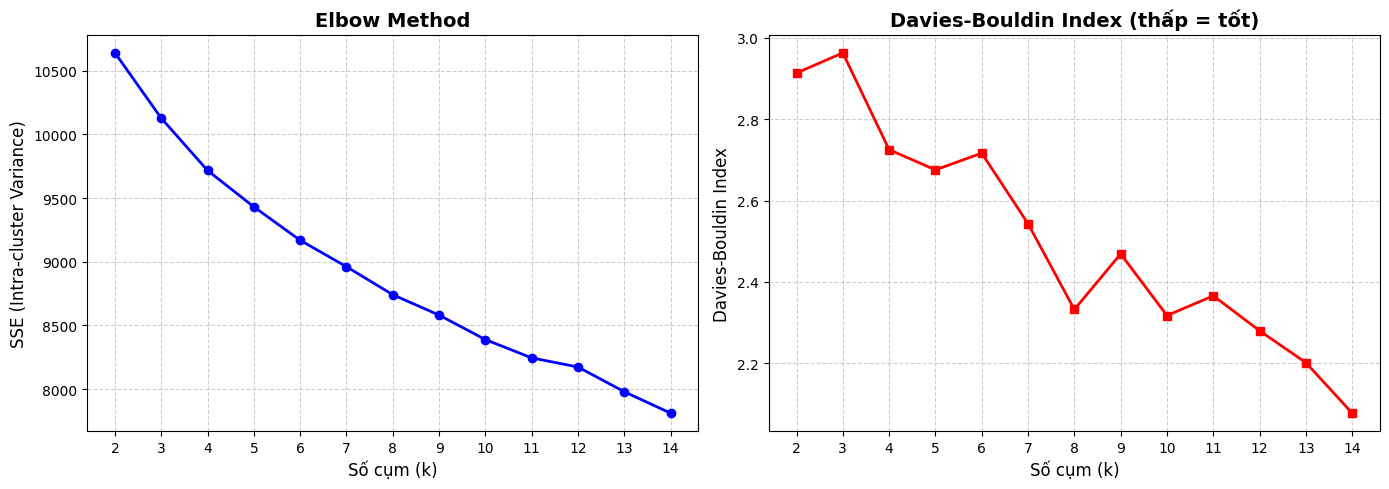

  k           SSE   Davies-Bouldin
----------------------------------
  2       10639.9           2.9132
  3       10126.9           2.9627
  4        9716.5           2.7250
  5        9430.9           2.6753
  6        9168.6           2.7164
  7        8961.1           2.5431
  8        8741.3           2.3324
  9        8581.4           2.4690
 10        8389.0           2.3175
 11        8245.3           2.3660
 12        8173.8           2.2802
 13        7979.4           2.2017
 14        7811.4           2.0777


In [7]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5 — Chọn K tối ưu: Elbow + Davies-Bouldin
#
# Elbow  : SSE giảm chậm lại → điểm khuỷu tay = K tốt
# DB Index: càng nhỏ càng tốt (cluster compact và tách biệt nhau)
# ═══════════════════════════════════════════════════════════════════
k_range  = range(2, 15)
sse_list = []
db_list  = []

for k in k_range:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sse_list.append(km.inertia_)
    db_list.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), sse_list, 'bo-', linewidth=2, markersize=6)
axes[0].set_xlabel('Số cụm (k)', fontsize=12)
axes[0].set_ylabel('SSE (Intra-cluster Variance)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), db_list, 'rs-', linewidth=2, markersize=6)
axes[1].set_xlabel('Số cụm (k)', fontsize=12)
axes[1].set_ylabel('Davies-Bouldin Index', fontsize=12)
axes[1].set_title('Davies-Bouldin Index (thấp = tốt)', fontsize=14, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

print(f'{"k":>3}  {"SSE":>12}  {"Davies-Bouldin":>15}')
print('-' * 34)
for k, sse, db in zip(k_range, sse_list, db_list):
    print(f'{k:>3}  {sse:>12.1f}  {db:>15.4f}')

In [8]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6 — Chạy K-Means với K tối ưu
#          ↑ Chỉnh K_OPTIMAL dựa theo biểu đồ Elbow ở Cell 5
# ═══════════════════════════════════════════════════════════════════
K_OPTIMAL = 6

kmeans         = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# Gắn nhãn cluster vào user_genre_df (inactive users = NaN)
user_genre_df['cluster'] = np.nan
user_genre_df.loc[active_users.index, 'cluster'] = cluster_labels

db_final = davies_bouldin_score(X_scaled, cluster_labels)
print(f'K = {K_OPTIMAL}  |  Davies-Bouldin Index = {db_final:.4f}')
print()
print('Số user trong mỗi cluster:')
for cid, cnt in pd.Series(cluster_labels).value_counts().sort_index().items():
    print(f'  Cluster {cid}: {cnt} users')

K = 6  |  Davies-Bouldin Index = 2.7164

Số user trong mỗi cluster:
  Cluster 0: 90 users
  Cluster 1: 141 users
  Cluster 2: 17 users
  Cluster 3: 229 users
  Cluster 4: 64 users
  Cluster 5: 69 users


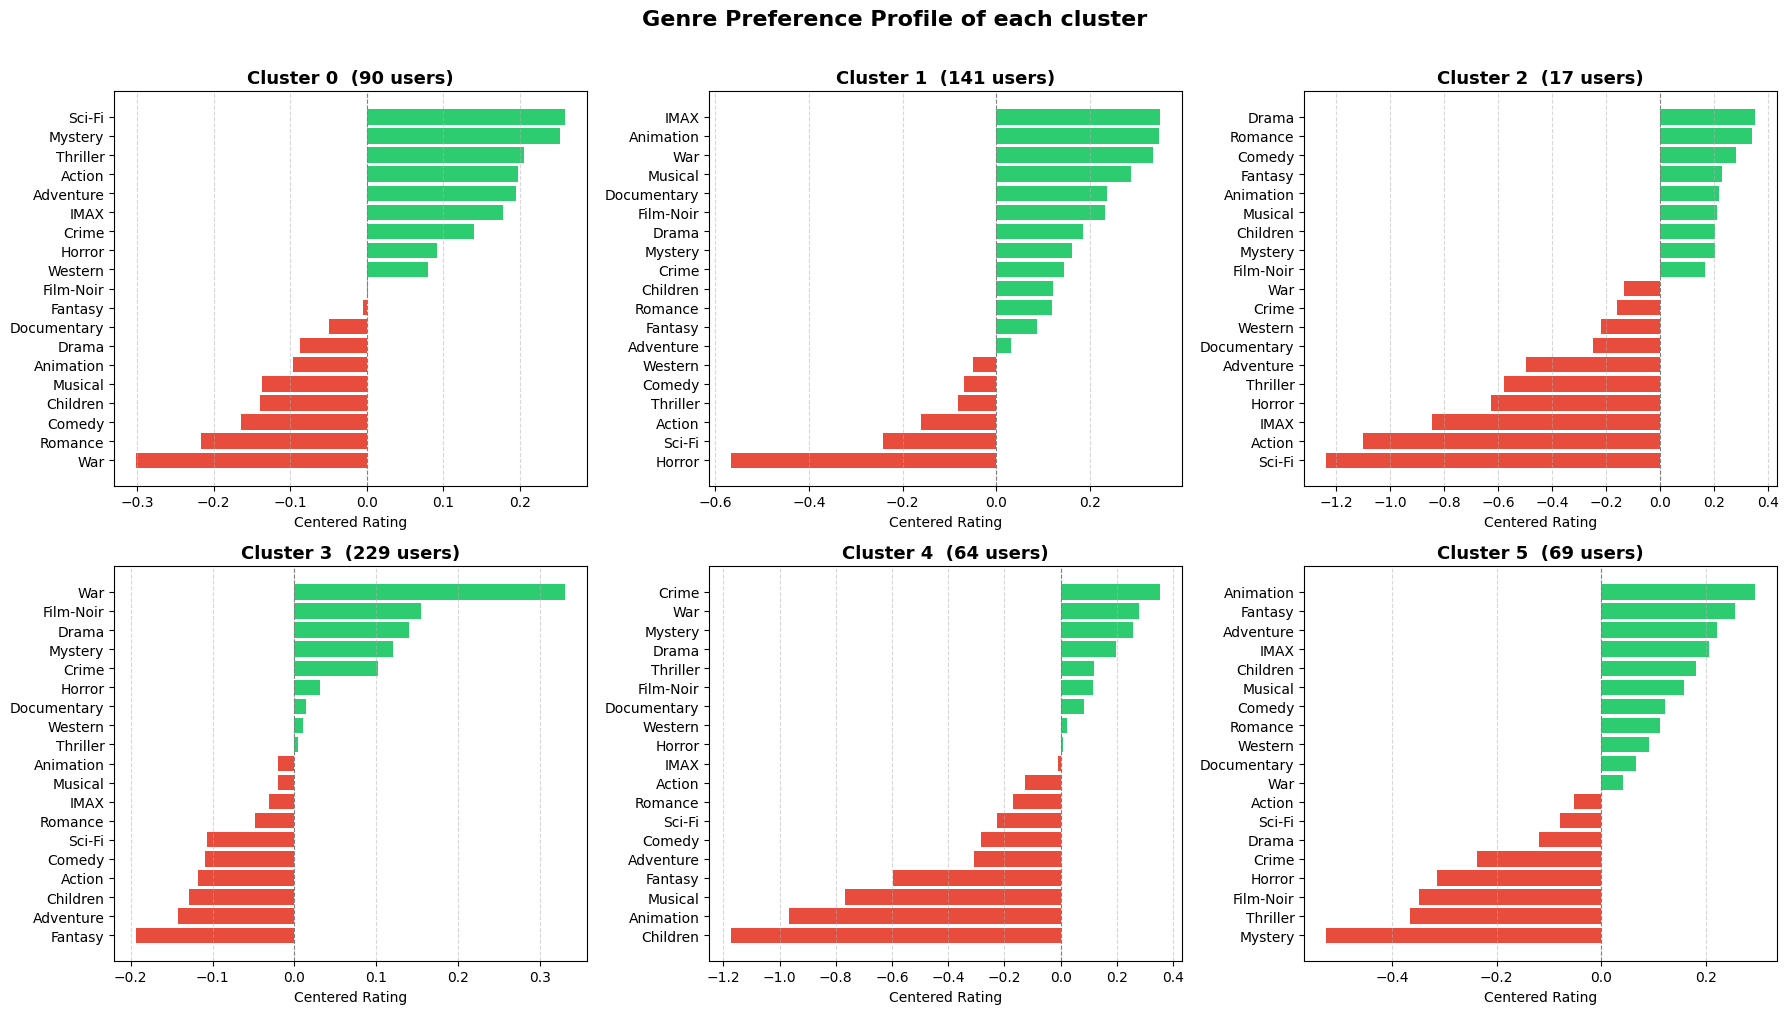

In [9]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7 — Phân tích đặc trưng từng cluster
#          Top genre nổi bật → hiểu cluster này thích thể loại nào
# ═══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for cid in range(K_OPTIMAL):
    cluster_idx = user_genre_df[user_genre_df['cluster'] == cid].index
    cluster_avg = user_genre_df.loc[cluster_idx, genre_cols].mean().sort_values(ascending=False)
    top_genres  = cluster_avg

    colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in top_genres.values]
    axes[cid].barh(top_genres.index[::-1], top_genres.values[::-1], color=colors[::-1])
    axes[cid].set_title(f'Cluster {cid}  ({len(cluster_idx)} users)', fontsize=13, fontweight='bold')
    axes[cid].set_xlabel('Centered Rating', fontsize=10)
    axes[cid].axvline(0, color='gray', linewidth=0.8, linestyle='--')
    axes[cid].grid(True, axis='x', linestyle='--', alpha=0.5)

plt.suptitle('Genre Preference Profile of each cluster', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [10]:
user_genre_df[['cluster']].head(20)

,cluster
userId,
1,1.0
2,1.0
3,0.0
4,3.0
5,1.0
6,5.0
7,3.0
8,1.0
9,1.0


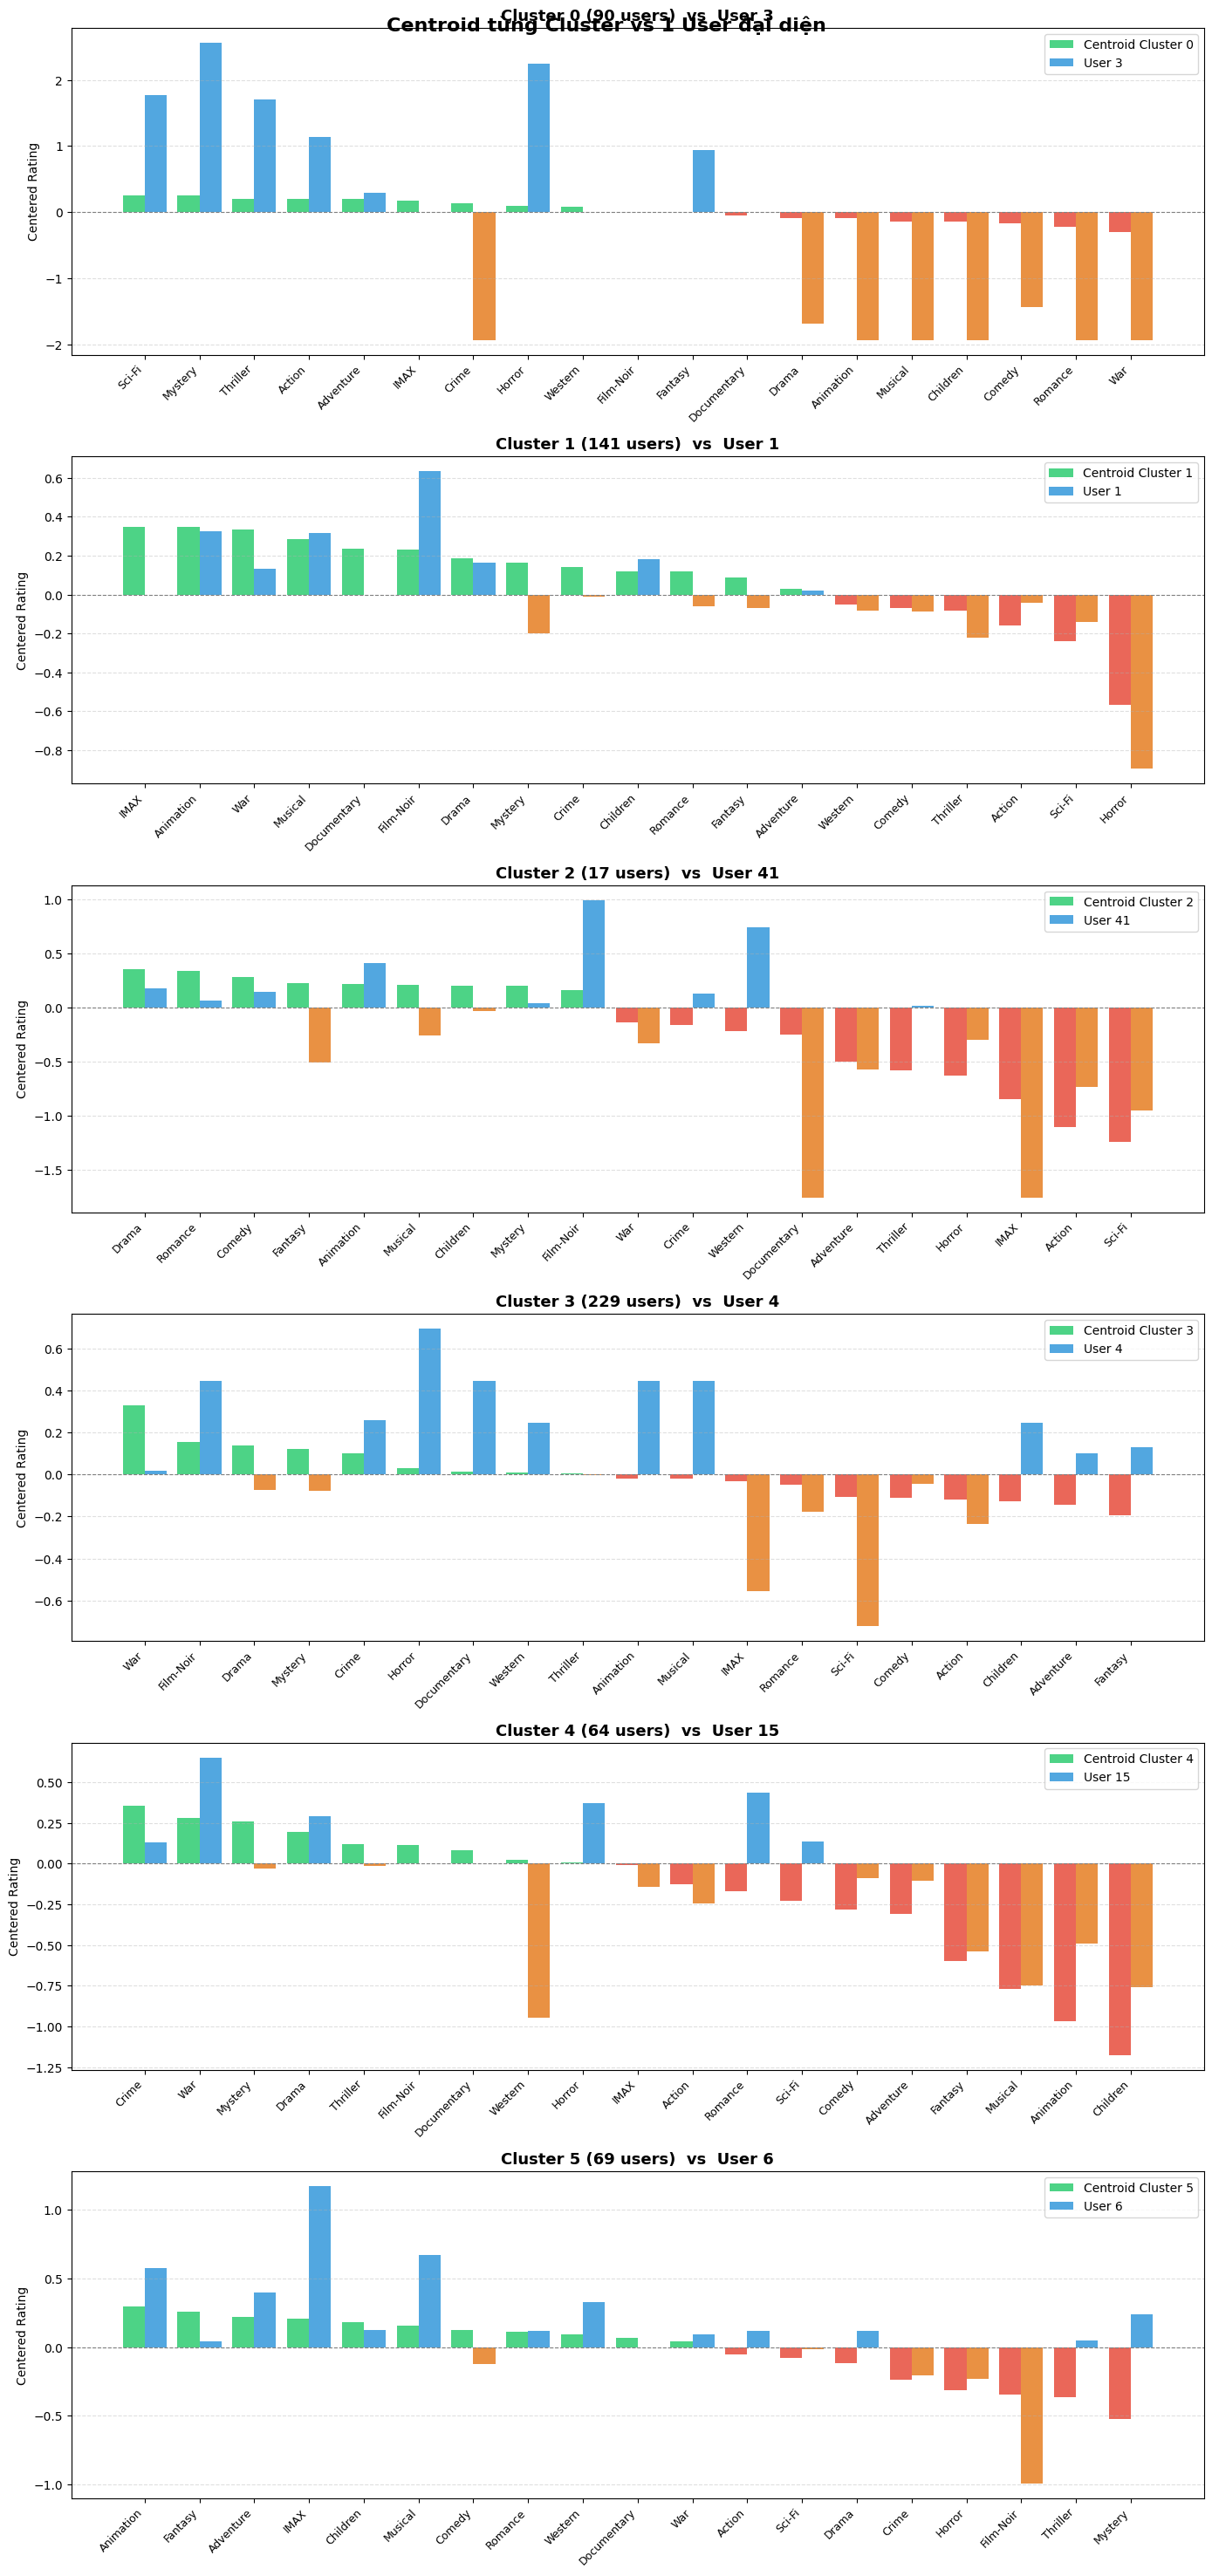

In [11]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7 — Phân tích đặc trưng từng cluster + so sánh với 1 user
# ═══════════════════════════════════════════════════════════════════
SAMPLE_USER_PER_CLUSTER = {cid: user_genre_df[user_genre_df['cluster'] == cid].index[0]
                           for cid in range(K_OPTIMAL)}
# Hoặc tự chọn tay: {0: 3, 1: 1, 2: 41, 3: 4, 4: 15, 5: 6}

fig, axes = plt.subplots(K_OPTIMAL, 1, figsize=(14, K_OPTIMAL * 5))

for cid in range(K_OPTIMAL):
    cluster_idx  = user_genre_df[user_genre_df['cluster'] == cid].index
    cluster_avg  = user_genre_df.loc[cluster_idx, genre_cols].mean().sort_values(ascending=False)

    sample_uid   = SAMPLE_USER_PER_CLUSTER[cid]
    user_vals    = user_genre_df.loc[sample_uid, genre_cols].reindex(cluster_avg.index)

    x      = np.arange(len(genre_cols))
    width  = 0.4
    ax     = axes[cid]

    bars_cluster = ax.bar(x - width/2, cluster_avg.values, width,
                          label=f'Centroid Cluster {cid}',
                          color=['#2ecc71' if v >= 0 else '#e74c3c' for v in cluster_avg.values],
                          alpha=0.85)
    bars_user    = ax.bar(x + width/2, user_vals.values, width,
                          label=f'User {sample_uid}',
                          color=['#3498db' if v >= 0 else '#e67e22' for v in user_vals.values],
                          alpha=0.85)

    ax.set_title(f'Cluster {cid} ({len(cluster_idx)} users)  vs  User {sample_uid}',
                 fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(cluster_avg.index, rotation=45, ha='right', fontsize=9)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_ylabel('Centered Rating')
    ax.legend(fontsize=10)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Centroid từng Cluster vs 1 User đại diện', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

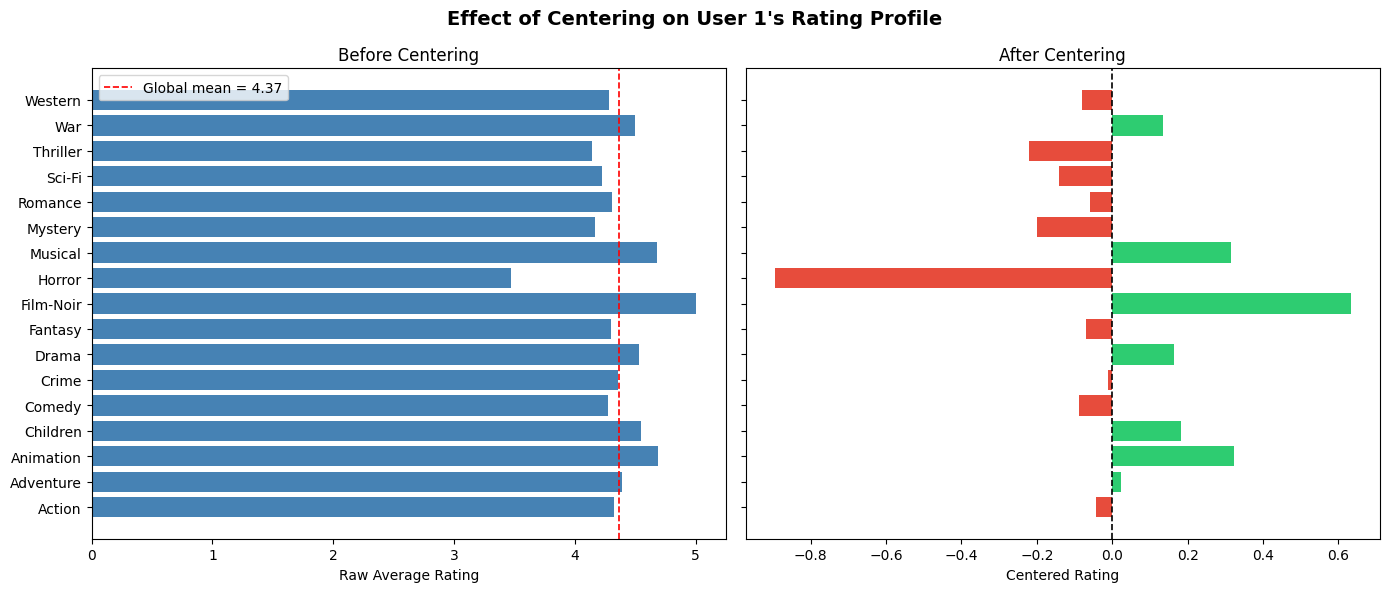

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Lấy data User 1
uid = 1
user_avg = user_genre_df.loc[uid, 'user_avg']
raw_avg  = genre_avg.loc[uid, genre_cols]       # raw per-genre average
centered = user_genre_df.loc[uid, genre_cols]   # centered

# Chỉ lấy genre user đã xem (raw != NaN trước fillna)
seen_mask = genre_count.loc[uid, genre_cols] > 0
raw_seen      = raw_avg[seen_mask]
centered_seen = centered[seen_mask]
genres_seen   = raw_seen.index.tolist()

x = np.arange(len(genres_seen))
colors_c = ['#2ecc71' if v >= 0 else '#e74c3c' for v in centered_seen]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle("Effect of Centering on User 1's Rating Profile", fontsize=14, fontweight='bold')

# LEFT — raw
axes[0].barh(x, raw_seen, color='steelblue')
axes[0].axvline(user_avg, color='red', linestyle='--', linewidth=1.2, label=f'Global mean = {user_avg:.2f}')
axes[0].set_yticks(x)
axes[0].set_yticklabels(genres_seen)
axes[0].set_xlabel('Raw Average Rating')
axes[0].set_title('Before Centering')
axes[0].legend()
axes[0].invert_yaxis()

# RIGHT — centered
axes[1].barh(x, centered_seen, color=colors_c)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2)
axes[1].set_xlabel('Centered Rating')
axes[1].set_title('After Centering')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [13]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8 — Định nghĩa các hàm Recommendation
#
# 3 trường hợp theo tài liệu:
# ┌────────────────────────────┬──────────────────────────────────────┐
# │ User mới (0 rating)        │ Hỏi genre → tìm cluster gần nhất    │
# │                            │ hoặc fallback popular                │
# ├────────────────────────────┼──────────────────────────────────────┤
# │ Ít rating (< threshold)    │ Dữ liệu yếu → fallback popular      │
# ├────────────────────────────┼──────────────────────────────────────┤
# │ Active user (>= threshold) │ K-Means → recommend từ cluster       │
# └────────────────────────────┴──────────────────────────────────────┘
# ═══════════════════════════════════════════════════════════════════

def recommend_from_cluster(cluster_id, exclude_movies=set(), exclude_user=None,
                           top_n=10, min_cluster_ratings=3):
    """
    Quy trình:
      lấy tất cả user cùng cluster
      → tính avg_rating từng phim trong nhóm
      → loại phim user đã xem
      → trả về top N
    """
    cluster_idx = user_genre_df[user_genre_df['cluster'] == cluster_id].index.tolist()
    if exclude_user is not None:
        cluster_idx = [u for u in cluster_idx if u != exclude_user]

    cluster_ratings = ratings[ratings['userId'].isin(cluster_idx)]
    movie_stats = cluster_ratings.groupby('movieId')['rating'].agg(
        avg_rating='mean', rating_count='count'
    )
    filtered = movie_stats[
        (movie_stats['rating_count'] >= min_cluster_ratings) &
        (~movie_stats.index.isin(exclude_movies))
    ]
    result = (
        filtered
        .sort_values(['avg_rating', 'rating_count'], ascending=[False, False])
        .head(top_n)
        .join(movies.set_index('movieId'), how='inner')
        .reset_index()
    )
    result['cluster'] = int(cluster_id)
    return result[['movieId', 'title', 'genres', 'avg_rating', 'rating_count', 'cluster']]


def recommend_popular(top_n=10, min_ratings=50):
    """Fallback: phim phổ biến nhất toàn hệ thống (popular + top-rated)."""
    movie_stats = ratings.groupby('movieId')['rating'].agg(
        avg_rating='mean', rating_count='count'
    )
    result = (
        movie_stats[movie_stats['rating_count'] >= min_ratings]
        .sort_values(['avg_rating', 'rating_count'], ascending=[False, False])
        .head(top_n)
        .join(movies.set_index('movieId'), how='inner')
        .reset_index()
    )
    result['cluster'] = -1  # -1 = popular fallback
    return result[['movieId', 'title', 'genres', 'avg_rating', 'rating_count', 'cluster']]


def recommend_for_existing_user(user_id, top_n=10):
    """Gợi ý cho user đã có trong hệ thống."""
    if user_id not in user_genre_df.index:
        print(f'❌ Không tìm thấy userId {user_id}')
        return None

    user_row     = user_genre_df.loc[user_id]
    rating_count = int(user_row['rating_count'])
    print(f'userId = {user_id}  |  Số phim đã rate: {rating_count}  |  user_avg: {user_row["user_avg"]:.2f}')

    if pd.isna(user_row['cluster']):
        print(f'⚠️  Ít hơn {MIN_RATINGS} ratings → Dữ liệu yếu → Popular Fallback')
        return recommend_popular(top_n=top_n)

    cluster_id = int(user_row['cluster'])
    watched    = set(ratings[ratings['userId'] == user_id]['movieId'])
    print(f'✅ Thuộc Cluster {cluster_id}  |  Đã xem: {len(watched)} phim')
    return recommend_from_cluster(cluster_id, exclude_movies=watched,
                                  exclude_user=user_id, top_n=top_n)


def recommend_for_new_user(favorite_genres=None, top_n=10):
    """Gợi ý cho user hoàn toàn mới (0 rating)."""
    if not favorite_genres:
        print('ℹ️  Không có genre → Popular Fallback')
        return recommend_popular(top_n=top_n)

    valid = [g for g in favorite_genres if g in genre_cols]
    if not valid:
        print(f'⚠️  Genres không hợp lệ. Hợp lệ: {genre_cols}')
        return recommend_popular(top_n=top_n)

    # Mock preference vector: +1.0 genre yêu thích, 0.0 còn lại
    pref_raw    = np.array([1.0 if g in valid else 0.0 for g in genre_cols]).reshape(1, -1)
    pref_scaled = scaler.transform(pref_raw)

    # Tìm cluster centroid gần nhất
    distances    = np.linalg.norm(kmeans.cluster_centers_ - pref_scaled, axis=1)
    best_cluster = int(np.argmin(distances))

    print(f'✅ Genres yêu thích: {valid}  →  Cluster phù hợp nhất: {best_cluster}')
    return recommend_from_cluster(best_cluster, exclude_movies=set(), top_n=top_n)


def get_user_watched(user_id, top_n=None):
    """Xem tất cả phim user đã rating, sắp xếp theo rating giảm dần."""
    if user_id not in ratings['userId'].values:
        print(f'❌ Không tìm thấy userId {user_id}')
        return None
    result = (
        ratings[ratings['userId'] == user_id]
        .merge(movies, on='movieId')[['movieId', 'title', 'genres', 'rating']]
        .sort_values('rating', ascending=False)
        .reset_index(drop=True)
    )
    result.index += 1
    return result.head(top_n) if top_n else result


print('✅ Các hàm recommendation sẵn sàng')
print(f'📋 Genres hợp lệ: {genre_cols}')

✅ Các hàm recommendation sẵn sàng
📋 Genres hợp lệ: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [14]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9 — Demo: Gợi ý cho user đã có trong hệ thống
# ═══════════════════════════════════════════════════════════════════
TARGET_USER = 1  # ← đổi userId tùy ý (1 – 610)

print(f'{'='*60}')
print(f'  Phim user {TARGET_USER} đã xem (top 10 theo rating)')
print(f'{'='*60}')
display(get_user_watched(TARGET_USER, top_n=10))

print()
print(f'{'='*60}')
print(f'  PHIM GỢI Ý CHO USER {TARGET_USER}')
print(f'{'='*60}')
recs = recommend_for_existing_user(TARGET_USER, top_n=10)
print()
display(recs)

  Phim user 1 đã xem (top 10 theo rating)


,movieId,title,genres,rating
1,5060,M*A*S*H (a.k.a. MASH) (1970),Comedy|Drama|War,5.0
2,2872,Excalibur (1981),Adventure|Fantasy,5.0
3,1291,Indiana Jones and the Last Crusade (1989),Action|Adventure,5.0
4,1298,Pink Floyd: The Wall (1982),Drama|Musical,5.0
5,2948,From Russia with Love (1963),Action|Adventure|Thriller,5.0
6,2947,Goldfinger (1964),Action|Adventure|Thriller,5.0
7,2944,"Dirty Dozen, The (1967)",Action|Drama|War,5.0
8,2899,Gulliver's Travels (1939),Adventure|Animation|Children,5.0
9,2858,American Beauty (1999),Drama|Romance,5.0
10,2700,"South Park: Bigger, Longer and Uncut (1999)",Animation|Comedy|Musical,5.0



  PHIM GỢI Ý CHO USER 1
userId = 1  |  Số phim đã rate: 232  |  user_avg: 4.37
✅ Thuộc Cluster 1  |  Đã xem: 232 phim



,movieId,title,genres,avg_rating,rating_count,cluster
0,3451,Guess Who's Coming to Dinner (1967),Drama,4.800000,5,1
1,3030,Yojimbo (1961),Action|Adventure,4.714286,7,1
2,3494,True Grit (1969),Adventure|Drama|Western,4.666667,3,1
3,1041,Secrets & Lies (1996),Drama,4.625000,4,1
4,3083,All About My Mother (Todo sobre mi madre) (1999),Drama,4.625000,4,1
5,112175,How to Train Your Dragon 2 (2014),Action|Adventure|Animation,4.625000,4,1
6,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.592105,76,1
7,955,Bringing Up Baby (1938),Comedy|Romance,4.571429,7,1
8,750,Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),Comedy|War,4.500000,23,1
9,475,In the Name of the Father (1993),Drama,4.500000,13,1


In [15]:
# ═══════════════════════════════════════════════════════════════════
# CELL 10 — Demo: Gợi ý cho user mới
# ═══════════════════════════════════════════════════════════════════

# Trường hợp 1: User mới có genre yêu thích
print('='*60)
print('  USER MỚI — drama + war + comedy')
print('='*60)
recs_new = recommend_for_new_user(favorite_genres=['Drama', 'War','crime'], top_n=10)
print()
display(recs_new)

print()

# Trường hợp 2: User mới không chọn genre → fallback popular
print('='*60)
print('  USER MỚI — không chọn genre → Popular Fallback')
print('='*60)
recs_popular = recommend_popular(top_n=10)
print()
display(recs_popular)

  USER MỚI — drama + war + comedy
✅ Genres yêu thích: ['Drama', 'War']  →  Cluster phù hợp nhất: 3



,movieId,title,genres,avg_rating,rating_count,cluster
0,720,Wallace & Gromit: The Best of Aardman Animation (1996),Adventure|Animation|Comedy,4.900000,5,3
1,3435,Double Indemnity (1944),Crime|Drama|Film-Noir,4.900000,5,3
2,3468,"Hustler, The (1961)",Drama,4.900000,5,3
3,6460,"Trial, The (Procès, Le) (1962)",Drama,4.875000,4,3
4,3201,Five Easy Pieces (1970),Drama,4.833333,3,3
5,7669,Pride and Prejudice (1995),Drama|Romance,4.833333,3,3
6,9010,Love Me If You Dare (Jeux d'enfants) (2003),Drama|Romance,4.833333,3,3
7,55167,Tekkonkinkreet (Tekkon kinkurîto) (2006),Action|Adventure|Animation|Crime|Fantasy,4.833333,3,3
8,1041,Secrets & Lies (1996),Drama,4.800000,5,3
9,177593,"Three Billboards Outside Ebbing, Missouri (2017)",Crime|Drama,4.800000,5,3



  USER MỚI — không chọn genre → Popular Fallback



,movieId,title,genres,avg_rating,rating_count,cluster
0,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.429022,317,-1
1,858,"Godfather, The (1972)",Crime|Drama,4.289062,192,-1
2,2959,Fight Club (1999),Action|Crime|Drama|Thriller,4.272936,218,-1
3,1276,Cool Hand Luke (1967),Drama,4.271930,57,-1
4,750,Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),Comedy|War,4.268041,97,-1
5,904,Rear Window (1954),Mystery|Thriller,4.261905,84,-1
6,1221,"Godfather: Part II, The (1974)",Crime|Drama,4.259690,129,-1
7,48516,"Departed, The (2006)",Crime|Drama|Thriller,4.252336,107,-1
8,1213,Goodfellas (1990),Crime|Drama,4.250000,126,-1
9,912,Casablanca (1942),Drama|Romance,4.240000,100,-1


In [16]:
# ═══════════════════════════════════════════════════════════════════
# CELL 11 — Interactive: Nhập User ID từ bàn phím
# ═══════════════════════════════════════════════════════════════════
user_input = int(input('Nhập User ID (1–610): '))

print()
print(f'{'='*60}')
print(f'  PHIM GỢI Ý CHO USER {user_input}')
print(f'{'='*60}')
recs_input = recommend_for_existing_user(user_input, top_n=10)
if recs_input is not None:
    print()
    display(recs_input)


  PHIM GỢI Ý CHO USER 1
userId = 1  |  Số phim đã rate: 232  |  user_avg: 4.37
✅ Thuộc Cluster 1  |  Đã xem: 232 phim



,movieId,title,genres,avg_rating,rating_count,cluster
0,3451,Guess Who's Coming to Dinner (1967),Drama,4.800000,5,1
1,3030,Yojimbo (1961),Action|Adventure,4.714286,7,1
2,3494,True Grit (1969),Adventure|Drama|Western,4.666667,3,1
3,1041,Secrets & Lies (1996),Drama,4.625000,4,1
4,3083,All About My Mother (Todo sobre mi madre) (1999),Drama,4.625000,4,1
5,112175,How to Train Your Dragon 2 (2014),Action|Adventure|Animation,4.625000,4,1
6,318,"Shawshank Redemption, The (1994)",Crime|Drama,4.592105,76,1
7,955,Bringing Up Baby (1938),Comedy|Romance,4.571429,7,1
8,750,Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964),Comedy|War,4.500000,23,1
9,475,In the Name of the Father (1993),Drama,4.500000,13,1
